In [1]:
import os

###############################################################################
# Decide on CPU or GPU here
use_gpu = True  # Set to False if you want CPU only
###############################################################################

if use_gpu:
    # Prevent JAX from preallocating most of the GPU memory
    os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
    # Force JAX to use GPU
    import jax
    jax.config.update("jax_platform_name", "gpu")
else:
    # Force JAX to use CPU
    import jax
    jax.config.update("jax_platform_name", "cpu")

In [2]:
import numpy as np
from jax import jit, vjp, vmap, value_and_grad, random, nn, lax
import jax
from jax import numpy as jnp
from jax import lax
from jaxdf.operators import compose
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from IPython.display import display, clear_output

# from cmcrameri import cm

import optax
import equinox as eqx
from jax.example_libraries import optimizers
from typing import Tuple, Callable, Optional, Union


from jwave.geometry import Domain, Medium
from jwave.signal_processing import smooth

key = random.PRNGKey(42)  # Random seed
Array = jnp.ndarray

from tqdm.auto import trange


from jax.example_libraries import optimizers


from hybridoed.forward import create_src_field, generate_2D_gridded_src_rec_positions, ricker_wavelet, acoustic2D, acoustic2D_pml,acoustic2D_pml_minmem, acoustic2D_pml_4th_minmem, generate_src_rec_positions, acoustic2D_cpml_minmem, cfl_dt, solve_phi_wave_2d

from hybridoed.oed import *


2026-03-12 18:13:36.568597: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.5.82. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.
/home/merciera/miniconda3/envs/hybridOED/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:


# ---- physical domain (meters) ----
Lx, Ly = 0.6, 0.6               # FIXED domain size
c_min = 1300.0            
c_max = 5750.0    

# ---- material model (fixed in meters) ----
velocity = c_min
density  = 1180.0        

# ---- resolution chosen ONCE for the highest test frequency ----
f0_max = 25e3                     # highest center freq you'll run
fmax   = 2.0 * f0_max             # Ricker top-end
PPW    = 8                       # for 2nd-order space; 10–12 is typical

dx_req = c_min / (PPW * fmax)
dx = dy = dx_req                  # keep this fixed for all runs

# grid size from physical size
nx = int(np.floor(Lx / dx)) + 1
ny = int(np.floor(Ly / dy)) + 1
dx = Lx / (nx - 1)                # snap dx to fit exactly
dy = Ly / (ny - 1)

print(f"nx, ny = {nx}, {ny}  |  dx = {dx*1e3:.2f} mm, dy = {dy*1e3:.2f} mm")

# ---- stable time step (keep FIXED) ----
dt_max = min(dx,dy) / (c_max * np.sqrt(2.0))   # 2-D CFL for staggered first-order
dt = 0.8 * dt_max                              # margin
print(f"dt = {dt*1e6:.2f} µs")

# ---- PML thickness in METERS (fixed), converted to cells ----
pml_thickness_m = 0.1                         # e.g., 3 cm per side
pml_width = max(4, int(round(pml_thickness_m / dx)))
print(f"pml_width = {pml_width} cells (~{pml_width*dx*100:.1f} cm)")



true_model = jnp.full((nx, ny), velocity, dtype=jnp.float32)
homo_model = jnp.full((nx, ny), velocity, dtype=jnp.float32)
# scatterer defined in METERS, then mapped to indices
scx0, scx1 = 0.05+0.15 +0.05-0.035/2,  0.05+0.15 +0.05+0.035/2 
scy0, scy1 =  0.15+0.15+0.05-0.035/2,  0.15+0.15+0.05+0.035/2  
# diag_add = 0.15
# scx0, scx1 = diag_add + 0.15 +0.05-0.035/2, diag_add + 0.15 +0.05+0.035/2 
# scy0, scy1 = diag_add + 0.15+0.05-0.035/2, diag_add + 0.15+0.05+0.035/2
ix0, ix1 = int(scx0/dx), int(scx1/dx)
iy0, iy1 = int(scy0/dy), int(scy1/dy)
true_model = true_model.at[ix0:ix1, iy0:iy1].set(c_max)

# make a blurred version of the true model for the homogeneous case
from scipy.ndimage import gaussian_filter as gaussian
# true_model_np = np.array(true_model)
# homo_model_np = gaussian(true_model_np, sigma=5)
# homo_model = jnp.array(homo_model_np, dtype=jnp.float32)

density_grid = jnp.full_like(true_model, density)
density_grid = density_grid.at[ix0:ix1, iy0:iy1].set(4500.0)  # set density in scatterer

density_grid_homo = jnp.full_like(homo_model, density)

# ---- geometry in METERS (then to index floats) ----
# One source 2 cm from left wall, centered vertically
# src_x_m, src_y_m = 0.3,0.3
# define a 2D grid of sources        
src_x_m_list = np.linspace(0.15, 0.45, 3)  # reverse to have source on the left for plotting
src_y_m_list = np.linspace(0.15, 0.45, 3)
src_indices = []
for x in src_x_m_list:
    for y in src_y_m_list:
        src_indices.append([x / dx, y / dy])

src_indices = jnp.array(src_indices, dtype=jnp.float32)

# 2D grid of receivers: 
n_rx, n_ry = 30,30
rec_x_m = np.linspace(0.15, 0.45, n_rx)  # reverse to match source side for plotting
rec_y_m = np.linspace(0.15, 0.45, n_ry)
rec_xx, rec_yy = np.meshgrid(rec_x_m, rec_y_m, indexing='ij')
receiver_is = jnp.stack([rec_xx.ravel() / dx, rec_yy.ravel() / dy], axis=1).astype(jnp.float32)

# ---- time window FIXED in seconds ----
T = 500e-6                     # e.g., 120 µs fixed
n_steps = int(np.ceil(T / dt))
print(f"n_steps = {n_steps}, total time = {n_steps*dt*1e6:.1f} µs")

# ---- run for any f0 (ONLY f0 changes) ----
f0 = 25e3  # try 10e3, 25e3, 40e3 without changing grid/dt
seis_total = []
seis_homo_total = []

def _run_one_source(src_xy):
    ys = acoustic2D_cpml_minmem(
        true_model, density_grid, src_xy, f0,
        dx, dy, dt, n_steps,
        receiver_is=receiver_is,
        output_wavefield=True,
        pml_width=pml_width,
        R_coeff=1e-6, m=3, kappa_max=3.0, alpha_max=None
    )
    ys_homo = acoustic2D_cpml_minmem(
        homo_model, density_grid_homo, src_xy, f0,
        dx, dy, dt, n_steps,
        receiver_is=receiver_is,
        output_wavefield=True,
        pml_width=pml_width,
        R_coeff=1e-6, m=3, kappa_max=3.0, alpha_max=None
    )
    return ys[0], ys_homo[0], ys[1]  # seis, seis_homo, wavefield

seis_total, seis_homo_total, wavefields_all = jax.lax.map(_run_one_source, src_indices)
wavefields_test = wavefields_all[-1] 




time = jnp.arange(n_steps) * dt

seis_total = jnp.array(seis_total)
seis_homo_total = jnp.array(seis_homo_total)
seis_total = jnp.swapaxes(seis_total, -1, -2)
seis_homo_total = jnp.swapaxes(seis_homo_total, -1, -2)


nx, ny = 185, 185  |  dx = 3.26 mm, dy = 3.26 mm
dt = 0.32 µs
pml_width = 31 cells (~10.1 cm)
n_steps = 1559, total time = 500.1 µs


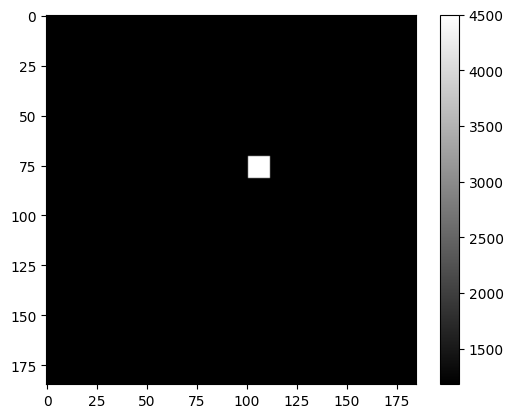

In [4]:
plt.imshow(density_grid, cmap='grey')
plt.colorbar()

distance between src-rec: 0.417013


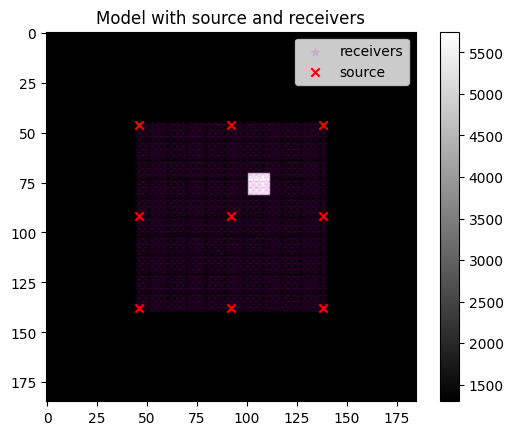

In [5]:
src_idx_to_plot = 0
rec_idx_to_plot = 869
# plt.scatter(receiver_is[rec_idx_to_plot,1], receiver_is[rec_idx_to_plot,0], c="m", marker="*", label="receivers", alpha=0.99)
# plt.scatter(src_indices[src_idx_to_plot][1], src_indices[src_idx_to_plot][0], c="r", marker="x", label="source")

print("distance between src-rec: {:.6f}".format(jnp.sqrt(
        (receiver_is[rec_idx_to_plot,0] - src_indices[src_idx_to_plot,0])**2 +
        (receiver_is[rec_idx_to_plot,1] - src_indices[src_idx_to_plot,1])**2) * dx))


plt.scatter(receiver_is[:,1], receiver_is[:,0], c="m", marker="*", label="receivers", alpha=0.1)

plt.scatter(src_indices[:,1], src_indices[:,0], c="r", marker="x", label="source")
plt.imshow(true_model, cmap='grey')
plt.colorbar()
plt.legend()
plt.title("Model with source and receivers")
plt.show()

In [6]:
# make a shot gather with the x axis being the y position
# sorte the trace by y position
source_x, source_y = src_indices[0][0], src_indices[0][1]
receiver_x, receiver_y = receiver_is[:,0], receiver_is[:,1]
sorted_indices_y = np.argsort(receiver_y)
sorted_offsets_y = receiver_y[sorted_indices_y]
sorted_traces_y = seis_total[:, sorted_indices_y]
n_traces_y = sorted_traces_y.shape[1]
n_samples_y = sorted_traces_y.shape[0]

# sorted_traces_y_solve = out["phi_rec"][:, sorted_indices_y]

# extract a receiver line at a fixed x position (e.g., the middle of the domain)
fixed_x = Lx / 2
# find the receiver closest to this x position
closest_idx = np.argmin(np.abs(receiver_x - fixed_x))
fixed_x_trace = seis_total[:, closest_idx]


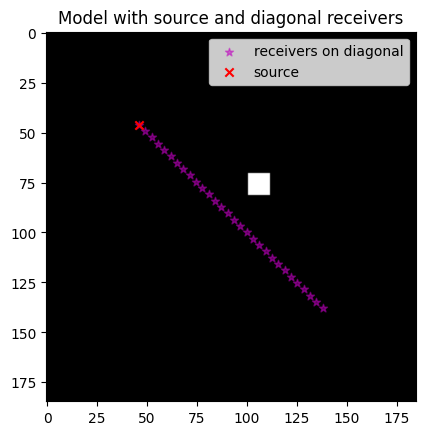

In [7]:
# plot only the receivers on the diagonal
receiver_is_diag = receiver_is[receiver_is[:,0] == receiver_is[:,1]]
plt.scatter(receiver_is_diag[:,1], receiver_is_diag[:,0], c="m", marker="*", label="receivers on diagonal", alpha=0.5)
plt.scatter(source_x, source_y, c="r", marker="x", label="source")
plt.imshow(true_model,cmap='grey')
plt.legend()
plt.title("Model with source and diagonal receivers")
plt.show()

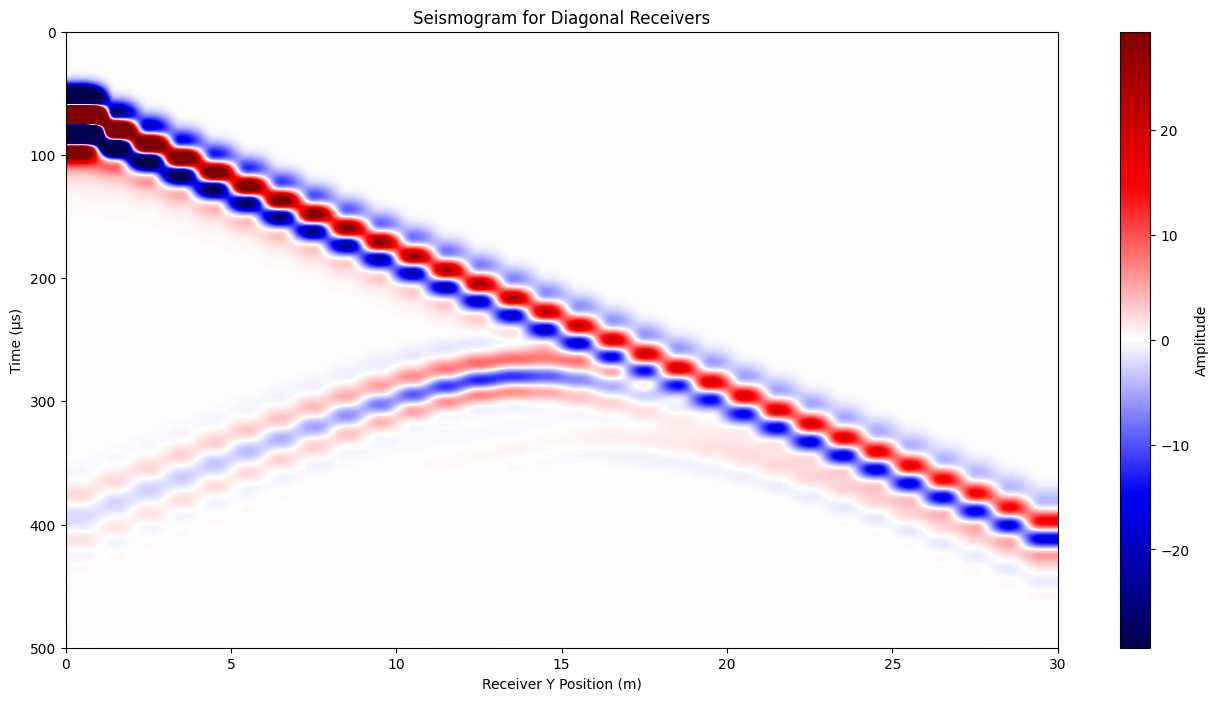

In [8]:
# plot only the traces from the diagonal receivers as an image
plt.figure(figsize=(16,8))
receiver_is_diag = receiver_is[receiver_is[:,0] == receiver_is[:,1]]
diag_indices = np.where((receiver_is[:,0] == receiver_is[:,1]))[0]
# diag_traces = out["phi_rec"][:, diag_indices]
diag_traces = seis_total[:, diag_indices]
# plt.imshow(diag_traces, aspect='auto', extent=[ receiver_is[diag_indices,1].min() * dx, receiver_is[diag_indices,1].max() * dx,time[-1]*1e6,0],cmap='seismic', vmin=-np.max(np.abs(diag_traces))/10, vmax=np.max(np.abs(diag_traces))/10)
plt.imshow(diag_traces[0].T, aspect='auto', extent=[0,30, T*1e6,0],cmap='seismic', vmin=-np.max(np.abs(diag_traces))/10, vmax=np.max(np.abs(diag_traces))/10)
plt.colorbar(label='Amplitude')
plt.ylabel('Time (µs)')
plt.xlabel('Receiver Y Position (m)')
plt.title('Seismogram for Diagonal Receivers')
plt.show()

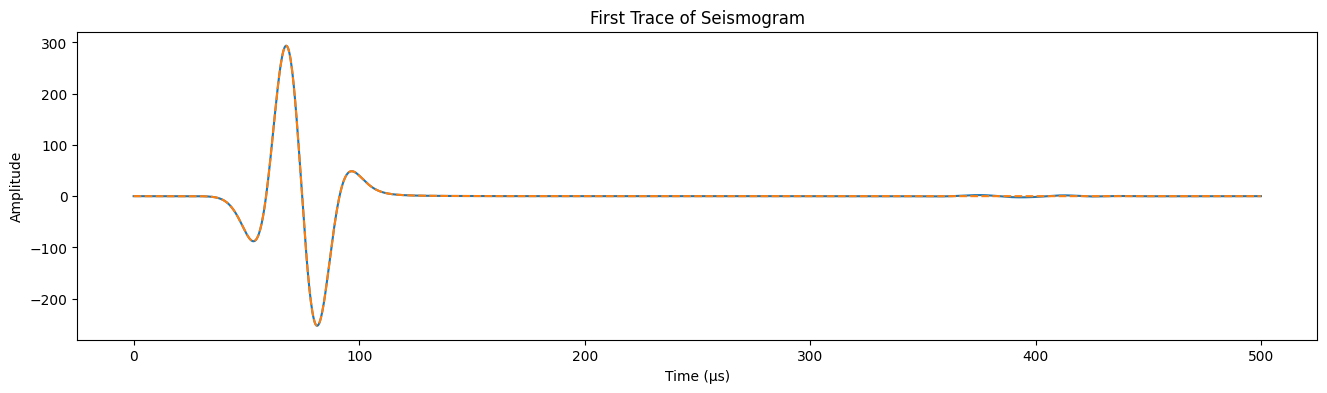

In [9]:
# plot only the firts trace
# plt.plot(time*1e6, out["phi_rec"][:, 0])
plt.figure(figsize=(16,4))
plt.plot(time*1e6, seis_total[0,0, :], label="Original")
plt.plot(time*1e6, seis_homo_total[0,0, :], label="Homogeneous", linestyle='--')
# plt.plot(time*1e6, out["phi_rec"][:, 0])
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude')
plt.title('First Trace of Seismogram')
plt.show()

In [10]:
# old non JAX implementation

# def apply_dispersion_phase_shift(
#     traces: np.ndarray,
#     dt: float,
#     dist: np.ndarray,
#     cp_of_f,
#     c_ref: float,
#     fmin: float | None = None,
#     fmax: float | None = None,
#     phase_only: bool = True,
#     eps: float = 1e-12,
# ) -> np.ndarray:
#     """
#     Apply an 'engineering' dispersive correction by phase-shifting in frequency domain.

#     Parameters
#     ----------
#     traces : (n_traces, n_samples) array
#         Time series at each receiver.
#     dt : float
#         Sampling interval [s].
#     dist : (n_traces,) array
#         Source-to-receiver distance for each trace [m].
#     cp_of_f : callable or (f, cp) tuple
#         If callable: cp_of_f(f_hz) -> phase velocity [m/s] for array f_hz.
#         If tuple: (f_hz_array, cp_array) used with linear interpolation.
#     c_ref : float
#         Reference (nondispersive) velocity used in your acoustic simulation [m/s].
#     fmin, fmax : float or None
#         Optional band-limits [Hz] where dispersion is applied.
#         Outside the band, no phase correction is applied.
#     phase_only : bool
#         If True, keep amplitude unchanged (recommended). If False, you can extend this
#         later to include attenuation (not implemented here).
#     eps : float
#         Small number to avoid division by zero.

#     Returns
#     -------
#     disp_traces : (n_traces, n_samples) jnp array
#         Dispersed traces.
#     """
#     import jax.numpy as jnp
    
#     traces = jnp.asarray(traces, dtype=float)
#     dist = jnp.asarray(dist, dtype=float)

#     if traces.ndim != 2:
#         raise ValueError("traces must be 2D (n_traces, n_samples)")
#     n_tr, nt = traces.shape
#     if dist.shape != (n_tr,):
#         raise ValueError(f"dist must have shape (n_traces,), got {dist.shape}")

#     # Build cp(f) accessor
#     if isinstance(cp_of_f, tuple) or isinstance(cp_of_f, list):
#         f_tab = jnp.asarray(cp_of_f[0], dtype=float)
#         cp_tab = jnp.asarray(cp_of_f[1], dtype=float)
#         if f_tab.ndim != 1 or cp_tab.ndim != 1 or f_tab.size != cp_tab.size:
#             raise ValueError("cp_of_f as tuple must be (f_array, cp_array) with same length")

#         def _cp(f_hz: np.ndarray) -> np.ndarray:
#             f_clipped = jnp.clip(f_hz, f_tab.min(), f_tab.max())
#             return jnp.interp(f_clipped, f_tab, cp_tab)
#     elif callable(cp_of_f):
#         _cp = cp_of_f
#     else:
#         raise ValueError("cp_of_f must be a callable or a (f_array, cp_array) tuple")

#     # Frequency axis for rFFT
#     f = np.fft.rfftfreq(nt, d=dt)
#     omega = 2.0 * np.pi * f

#     # Compute cp(f)
#     cp = np.asarray(_cp(f), dtype=float)
#     cp = np.maximum(cp, eps)

#     # Compute delta slowness and delta tau per trace
#     delta_s = (1.0 / cp) - (1.0 / max(c_ref, eps))
#     delta_tau = dist[:, None] * delta_s[None, :]

#     # Optional band-limit where to apply correction
#     if fmin is not None or fmax is not None:
#         mask = np.ones_like(f, dtype=bool)
#         if fmin is not None:
#             mask &= (f >= fmin)
#         if fmax is not None:
#             mask &= (f <= fmax)
#         delta_tau = np.where(mask[None, :], delta_tau, 0.0)

#     # FFT traces
#     U = np.fft.rfft(traces, axis=1)

#     # Apply phase shift
#     phase = np.exp(-1j * omega[None, :] * delta_tau)
#     U_disp = U * phase

#     # Back to time
#     disp_traces = np.fft.irfft(U_disp, n=nt, axis=1)

#     return jnp.asarray(disp_traces)


In [11]:
def apply_dispersion_phase_shift_jax(
    traces: Array,
    dt: float,
    dist: Array,
    c_ref: float,
    *,
    # Choose ONE of the two ways to provide cp(f):
    cp_fun: Optional[Callable[[Array], Array]] = None,
    cp_table: Optional[Tuple[Array, Array]] = None,  # (f_tab_hz, cp_tab)
    # Band limits:
    fmin: Optional[float] = None,
    fmax: Optional[float] = None,
    # Numerics:
    eps: float = 1e-12,
) -> Array:
    """
    JAX-differentiable dispersive correction by phase shifting in the frequency domain.

    Parameters
    ----------
    traces : (n_traces, n_samples) array
        Time series at each receiver.
    dt : float
        Sampling interval [s].
    dist : (n_traces,) array
        Source-to-receiver distance for each trace [m].
    c_ref : float
        Reference (nondispersive) velocity used in the acoustic simulation [m/s].
    cp_fun : callable, optional
        JAX-compatible function: cp_fun(f_hz) -> phase velocity [m/s] for f_hz array.
        NOTE: if you plan to `jit` this function, pass cp_fun as a *static* argument
        (see example below).
    cp_table : (f_tab_hz, cp_tab), optional
        Tabulated phase velocity. Uses linear interpolation (jnp.interp).
    fmin, fmax : optional float
        Frequency band [Hz] where dispersion is applied. Outside, no correction.
    eps : float
        Small number to avoid division by zero.

    Returns
    -------
    disp_traces : (n_traces, n_samples) array
        Dispersed traces (real-valued).
    """
    traces = jnp.asarray(traces)
    dist = jnp.asarray(dist)

    if traces.ndim != 2:
        raise ValueError("traces must be 2D (n_traces, n_samples)")
    n_tr, nt = traces.shape
    if dist.shape != (n_tr,):
        raise ValueError(f"dist must have shape (n_traces,), got {dist.shape}")

    # --- frequency axis (rFFT) ---
    f = jnp.fft.rfftfreq(nt, d=dt)  # (n_freq,)
    omega = 2.0 * jnp.pi * f

    # --- cp(f) ---
    if (cp_fun is None) == (cp_table is None):
        raise ValueError("Provide exactly one of cp_fun or cp_table.")

    if cp_table is not None:
        f_tab, cp_tab = cp_table
        f_tab = jnp.asarray(f_tab)
        cp_tab = jnp.asarray(cp_tab)
        if f_tab.ndim != 1 or cp_tab.ndim != 1 or f_tab.size != cp_tab.size:
            raise ValueError("cp_table must be (f_tab_1d, cp_tab_1d) with same length")

        f_clipped = jnp.clip(f, jnp.min(f_tab), jnp.max(f_tab))
        cp = jnp.interp(f_clipped, f_tab, cp_tab)
    else:
        cp = jnp.asarray(cp_fun(f))

    cp = jnp.maximum(cp, eps)
    c_ref_safe = jnp.maximum(jnp.asarray(c_ref, dtype=cp.dtype), eps) * 0.7  # the phase shift at 25khz is fixed to 0


    # delta_s(f) = 1/cp(f) - 1/c_ref
    delta_s = (1.0 / cp) - (1.0 / c_ref_safe)  # (n_freq,)

    # delta_tau(trace, f) = dist(trace) * delta_s(f)
    delta_tau = dist[:, None] * delta_s[None, :]  # (n_tr, n_freq)

    # --- optional band-limiting of the correction ---
    if (fmin is not None) or (fmax is not None):
        mask = jnp.ones_like(f, dtype=bool)
        if fmin is not None:
            mask = mask & (f >= fmin)
        if fmax is not None:
            mask = mask & (f <= fmax)
        delta_tau = jnp.where(mask[None, :], delta_tau, 0.0)

    # --- FFT, phase shift, iFFT ---
    U = jnp.fft.rfft(traces, axis=1)  # (n_tr, n_freq) complex
    phase = jnp.exp((-1j) * omega[None, :] * delta_tau)  # (n_tr, n_freq) complex
    U_disp = U * phase 
    disp_traces = jnp.fft.irfft(U_disp, n=nt, axis=1)  # (n_tr, nt) real

    return disp_traces


In [12]:
# JAX implementation with padding

# def apply_dispersion_phase_shift_jax(
#     traces: Array,
#     dt: float,
#     dist: Array,
#     c_ref: float,
#     *,
#     cp_fun: Optional[Callable[[Array], Array]] = None,
#     cp_table: Optional[Tuple[Array, Array]] = None,
#     fmin: Optional[float] = None,
#     fmax: Optional[float] = None,
#     eps: float = 1e-12,
#     pad_left: Optional[int] = None,
#     pad_right: Optional[int] = None,
#     pad_margin: int = 16,
# ) -> Array:
#     """
#     JAX-differentiable dispersive phase correction with zero-padding to avoid
#     circular wrap-around artifacts.

#     Parameters
#     ----------
#     traces : (n_traces, n_samples) array
#         Time series at each receiver.
#     dt : float
#         Sampling interval [s].
#     dist : (n_traces,) array
#         Source-to-receiver distance for each trace [m].
#     c_ref : float
#         Reference nondispersive velocity [m/s].
#     cp_fun : callable, optional
#         JAX-compatible function cp_fun(f_hz) -> cp(f) [m/s].
#     cp_table : (f_tab_hz, cp_tab), optional
#         Tabulated phase velocity, linearly interpolated.
#     fmin, fmax : float, optional
#         Frequency band in which to apply the dispersion correction.
#     eps : float
#         Numerical floor to avoid division by zero.
#     pad_left, pad_right : int, optional
#         Explicit zero-padding samples before / after each trace.
#         If None, padding is estimated automatically from the delay bounds.
#     pad_margin : int
#         Extra safety margin added to automatic padding.

#     Returns
#     -------
#     disp_traces : (n_traces, n_samples) array
#         Dispersed traces, cropped back to original length.
#     """
#     traces = jnp.asarray(traces)
#     dist = jnp.asarray(dist)

#     if traces.ndim != 2:
#         raise ValueError("traces must be 2D (n_traces, n_samples)")
#     n_tr, nt = traces.shape
#     if dist.shape != (n_tr,):
#         raise ValueError(f"dist must have shape (n_traces,), got {dist.shape}")

#     if (cp_fun is None) == (cp_table is None):
#         raise ValueError("Provide exactly one of cp_fun or cp_table.")

#     # ------------------------------------------------------------
#     # 1) Frequency axis on the ORIGINAL record, only to estimate delay bounds
#     # ------------------------------------------------------------
#     f0 = jnp.fft.rfftfreq(nt, d=dt)

#     if cp_table is not None:
#         f_tab, cp_tab = cp_table
#         f_tab = jnp.asarray(f_tab)
#         cp_tab = jnp.asarray(cp_tab)
#         if f_tab.ndim != 1 or cp_tab.ndim != 1 or f_tab.size != cp_tab.size:
#             raise ValueError("cp_table must be (f_tab_1d, cp_tab_1d) with same length")
#         f0_clip = jnp.clip(f0, jnp.min(f_tab), jnp.max(f_tab))
#         cp0 = jnp.interp(f0_clip, f_tab, cp_tab)
#     else:
#         cp0 = jnp.asarray(cp_fun(f0))

#     cp0 = jnp.maximum(cp0, eps)
#     c_ref_safe = jnp.maximum(jnp.asarray(c_ref, dtype=cp0.dtype), eps)

#     delta_s0 = (1.0 / cp0) - (1.0 / c_ref_safe)
#     delta_tau0 = dist[:, None] * delta_s0[None, :]

#     if (fmin is not None) or (fmax is not None):
#         mask0 = jnp.ones_like(f0, dtype=bool)
#         if fmin is not None:
#             mask0 = mask0 & (f0 >= fmin)
#         if fmax is not None:
#             mask0 = mask0 & (f0 <= fmax)
#         delta_tau0 = jnp.where(mask0[None, :], delta_tau0, 0.0)

#     # ------------------------------------------------------------
#     # 2) Choose padding so shifted energy does not wrap around
#     # ------------------------------------------------------------
#     # Positive delay -> needs padding on the right
#     # Negative delay -> needs padding on the left
#     if pad_left is None:
#         min_delay = float(jnp.min(delta_tau0))
#         pad_left = max(0, int(jnp.ceil(-min_delay / dt))) + pad_margin

#     if pad_right is None:
#         max_delay = float(jnp.max(delta_tau0))
#         pad_right = max(0, int(jnp.ceil(max_delay / dt))) + pad_margin

#     nt_pad = nt + pad_left + pad_right

#     # ------------------------------------------------------------
#     # 3) Zero-pad traces
#     # ------------------------------------------------------------
#     traces_pad = jnp.pad(
#         traces,
#         ((0, 0), (pad_left, pad_right)),
#         mode="constant",
#         constant_values=0.0,
#     )

#     # ------------------------------------------------------------
#     # 4) Frequency axis on PADDED record
#     # ------------------------------------------------------------
#     f = jnp.fft.rfftfreq(nt_pad, d=dt)
#     omega = 2.0 * jnp.pi * f

#     # ------------------------------------------------------------
#     # 5) Evaluate cp(f) on padded frequency axis
#     # ------------------------------------------------------------
#     if cp_table is not None:
#         f_clip = jnp.clip(f, jnp.min(f_tab), jnp.max(f_tab))
#         cp = jnp.interp(f_clip, f_tab, cp_tab)
#     else:
#         cp = jnp.asarray(cp_fun(f))

#     cp = jnp.maximum(cp, eps)

#     delta_s = (1.0 / cp) - (1.0 / c_ref_safe)
#     delta_tau = dist[:, None] * delta_s[None, :]

#     if (fmin is not None) or (fmax is not None):
#         mask = jnp.ones_like(f, dtype=bool)
#         if fmin is not None:
#             mask = mask & (f >= fmin)
#         if fmax is not None:
#             mask = mask & (f <= fmax)
#         delta_tau = jnp.where(mask[None, :], delta_tau, 0.0)

#     # ------------------------------------------------------------
#     # 6) FFT -> phase shift -> inverse FFT
#     # ------------------------------------------------------------
#     U = jnp.fft.rfft(traces_pad, axis=1)
#     phase = jnp.exp(-1j * omega[None, :] * delta_tau)
#     U_disp = U * phase
#     disp_pad = jnp.fft.irfft(U_disp, n=nt_pad, axis=1)

#     # ------------------------------------------------------------
#     # 7) Crop back to original window
#     # ------------------------------------------------------------
#     disp_traces = disp_pad[:, pad_left:pad_left + nt]

#     return disp_traces

In [13]:
import pandas as pd
# path to your exported file
file = "dispersion_curve_test_A_Lamb.txt"

# read file (it is comma-separated)
df = pd.read_csv(file)

f_A0 = df["A0 f (kHz)"].values
c_A0 = df["A0 Phase velocity (m/ms)"].values

# Remove NaNs (important: higher modes end earlier)
mask = ~np.isnan(f_A0) & ~np.isnan(c_A0)

f_A0 = f_A0[mask] * 1e3        # kHz → Hz
c_A0 = c_A0[mask] * 1e3        # m/ms → m/s

In [14]:
# traces: (nrec, nt)
# dt in seconds
# dist: (nrec,) in meters
# dist only for the diagonal receivers
# dist = np.sqrt((receiver_is[diag_indices,0] - source_x)**2 + (receiver_is[diag_indices,1] - source_y)**2) * dx
# Provide cp(f) as arrays (f_hz, cp_mps)
# f_cp = np.array([...])
# cp = np.array([...])

# disp = apply_dispersion_phase_shift(diag_traces.T, dt, dist, (f_A0, c_A0), c_ref=1200.0)

In [15]:
# lets now apply the dispersion correction to the compelte set of traces, not just the diagonal ones
# dist for all receivers
seis_traces_disp = []
for src in range(src_indices.shape[0]):
    dist_all = jnp.sqrt(
        (receiver_is[:,0] - src_indices[src,0])**2 +
        (receiver_is[:,1] - src_indices[src,1])**2) * dx
    print(dist_all.shape)

    out = apply_dispersion_phase_shift_jax(seis_total[src], dt, dist_all, c_ref=c_min, cp_table=(f_A0, c_A0),fmax=60e3)
    seis_traces_disp.append(out)


(900,)
(900,)
(900,)
(900,)
(900,)
(900,)
(900,)
(900,)
(900,)


In [16]:
dist_all[-30], jnp.max(dist_all)

(Array(0.3, dtype=float32), Array(0.424264, dtype=float32))

In [17]:
src

8

In [18]:
seis_traces_disp = jnp.array(seis_traces_disp)
seis_traces_disp.shape, seis_total.shape

((9, 900, 1559), (9, 900, 1559))

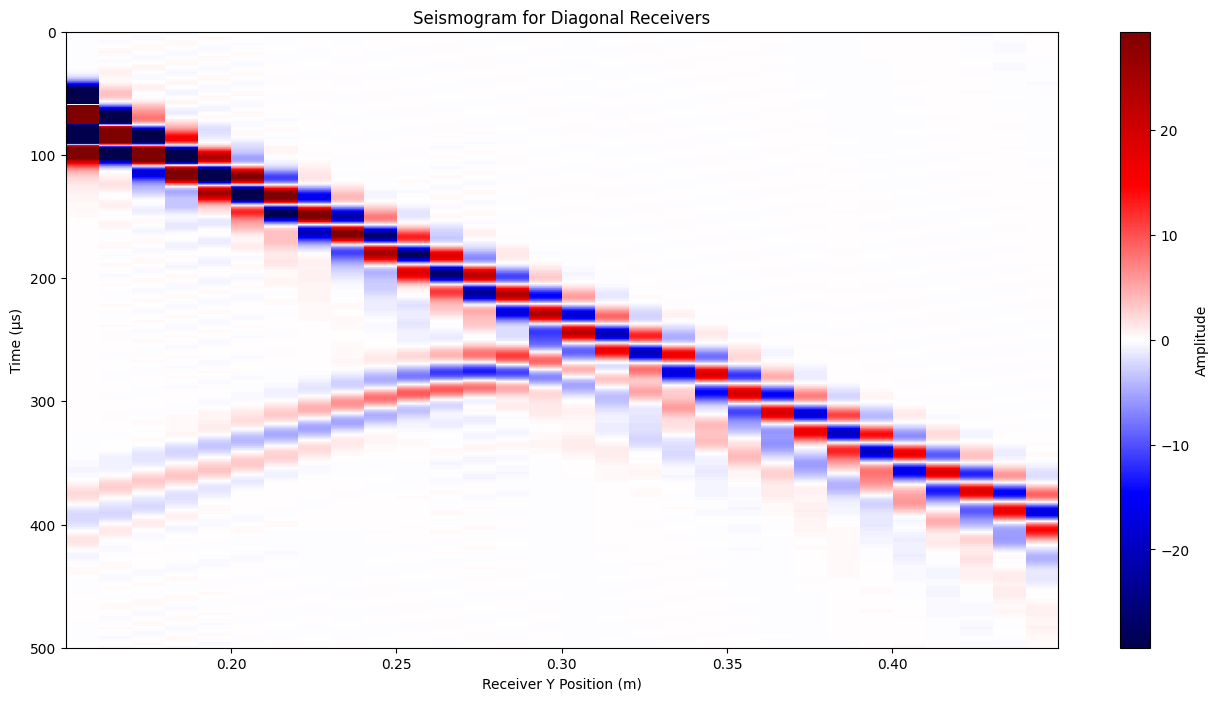

In [19]:
# plot only the traces from the diagonal receivers as an image
src_idx_to_plot = 0
rec_lines = receiver_is[:,0] == receiver_is[:,1]
plt.figure(figsize=(16,8))
plt.imshow(seis_traces_disp[src_idx_to_plot,rec_lines].T, aspect='auto', extent=[ receiver_is[diag_indices,1].min() * dx, receiver_is[diag_indices,1].max() * dx,T*1e6,0],cmap='seismic', vmin=-np.max(np.abs(seis_traces_disp[src_idx_to_plot]))/10, vmax=np.max(np.abs(seis_traces_disp[src_idx_to_plot]))/10,interpolation='none')
plt.colorbar(label='Amplitude')
plt.ylabel('Time (µs)')
plt.xlabel('Receiver Y Position (m)')
plt.title('Seismogram for Diagonal Receivers')
plt.show()

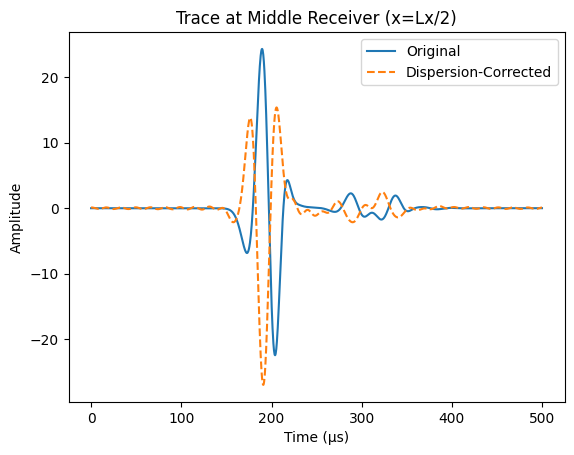

In [20]:
# plot the middle trace (closest to x=Lx/2)
# plt.plot(time*1e6, out["phi_rec"][:, 10], label="Original")
plt.plot(time*1e6, seis_total[0,15, :], label="Original")
plt.plot(time*1e6, seis_traces_disp[0,15,:], label="Dispersion-Corrected", linestyle='--')
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude')
plt.title('Trace at Middle Receiver (x=Lx/2)')
plt.legend()
plt.show()

In [21]:
# salvus_out = np.load("diagonal_traces_all.npz")  # assuming the traces are saved in a numpy file
# salvus_traces = salvus_out["diagonal_traces_all"] [0]
# salvus_traces.shape

In [22]:
seis_total.shape, time.shape, seis_traces_disp.shape

((9, 900, 1559), (1559,), (9, 900, 1559))

In [23]:
def extract_dispersion_fk(u, dt, dx):
    """
    Estimate dispersion curve from a receiver gather u(x, t).

    Parameters
    ----------
    u : ndarray, shape (nx, nt)
        Wavefield sampled along space and time.
    dt : float
        Time sampling interval [s].
    dx : float
        Receiver spacing [m].

    Returns
    -------
    f_pos : ndarray
        Positive frequencies [Hz].
    k_pick : ndarray
        Picked wavenumber [rad/m] for each frequency.
    cp : ndarray
        Estimated phase velocity [m/s].
    spectrum : ndarray
        2D FK spectrum (shifted in k, positive f only).
    k_axis : ndarray
        Wavenumber axis [rad/m].
    """
    nx, nt = u.shape

    # Remove mean
    u = u - np.mean(u, axis=1, keepdims=True)

    # Optional taper
    wx = np.hanning(nx)[:, None]
    wt = np.hanning(nt)[None, :]
    u_tapered = u * wx * wt

    # 2D FFT
    U_fk = np.fft.fft2(u_tapered)
    U_fk = np.fft.fftshift(U_fk, axes=0)  # shift k-axis only

    # Axes
    f = np.fft.fftfreq(nt, d=dt)                  # Hz
    k_cyc = np.fft.fftfreq(nx, d=dx)             # cycles/m
    k_cyc = np.fft.fftshift(k_cyc)
    k_axis = 2 * np.pi * k_cyc                   # rad/m

    # Keep only positive frequencies
    pos = f > 0
    f_pos = f[pos]
    spectrum = np.abs(U_fk[:, pos])

    # Pick ridge: max amplitude in k for each f
    idx_k = np.argmax(spectrum, axis=0)
    k_pick = np.abs(k_axis[idx_k])

    # Avoid division by zero
    cp = np.full_like(f_pos, np.nan, dtype=float)
    mask = k_pick > 0
    cp[mask] = 2 * np.pi * f_pos[mask] / k_pick[mask]

    return f_pos, k_pick, cp, spectrum, k_axis

In [24]:
# read the traces from salvus
# salvus_out = np.load("diagonal_traces_all.npz")  # assuming the traces are saved in a numpy file
salvus_out = np.load("all_traces.npz")
# salvus_traces = salvus_out["diagonal_traces_all"][-1] 
salvus_traces = salvus_out["all_traces"]
salvus_time = salvus_out["t"]

In [25]:
# extract a line of salvus data at fixed x (e.g., the middle of the domain)
print(salvus_traces.shape)
salvus_shot_6 = salvus_traces[6, :, :]
print(salvus_shot_6.shape)

# extract the receiver along the most left vertical line
salvus_shot_6_eft_line = [salvus_shot_6[i,:] for i in np.arange(0,900,30)]
salvus_shot_6_eft_line = np.array(salvus_shot_6_eft_line)
salvus_shot_6_eft_line.shape

(9, 900, 4031)
(900, 4031)


(30, 4031)

In [26]:
dt_salvus = salvus_time[1] - salvus_time[0]
dx_salvus = 0.01
f_pos, k_pick, cp, spectrum, k_axis = extract_dispersion_fk(salvus_shot_6_eft_line[:,:2900], dt_salvus, dx_salvus)

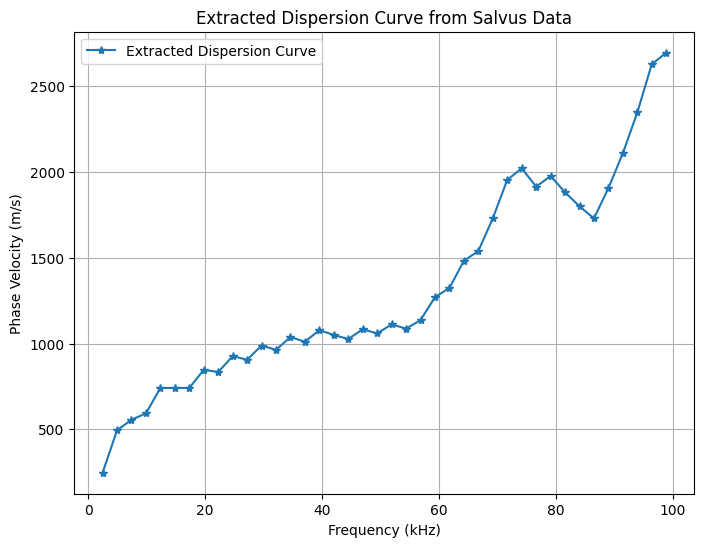

In [27]:
# plot the dispersion curve
plt.figure(figsize=(8,6))
plt.plot(f_pos[:40]*1e-3, cp[:40],"-*", label="Extracted Dispersion Curve")
plt.xlabel('Frequency (kHz)')
plt.ylabel('Phase Velocity (m/s)')
plt.title('Extracted Dispersion Curve from Salvus Data')
plt.grid()
plt.legend()
plt.show()

In [28]:
print(f_pos.min())

2471.04393636493


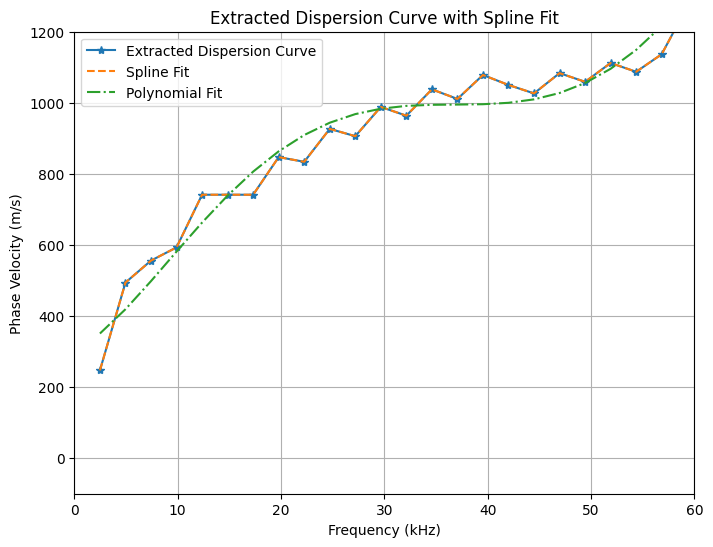

In [29]:
# fit a polynomial to the dispersion curve
from scipy.interpolate import UnivariateSpline
# Only fit up to 80 kHz to avoid high-frequency noise
fit_mask = f_pos < 80e3
spline = UnivariateSpline(f_pos[fit_mask], cp[fit_mask], k=1, s=0.001)
cp_spline = spline(f_pos)

# make a much smooter spline or polynomial fit to the dispersion curve
poly_coeffs = np.polyfit(f_pos[fit_mask], cp[fit_mask], deg=5)
cp_poly = np.polyval(poly_coeffs, f_pos)

plt.figure(figsize=(8,6))
plt.plot(f_pos[:40]*1e-3, cp[:40],"-*", label="Extracted Dispersion Curve")
plt.plot(f_pos[:40]*1e-3, cp_spline[:40], label="Spline Fit", linestyle='--')
plt.plot(f_pos[:40]*1e-3, cp_poly[:40], label="Polynomial Fit", linestyle='-.')
plt.ylim(-100, 1200)
plt.xlim(0, 60)
plt.xlabel('Frequency (kHz)')
plt.ylabel('Phase Velocity (m/s)')
plt.title('Extracted Dispersion Curve with Spline Fit')
plt.grid()
plt.legend()
plt.show()

In [30]:
cp_fun = lambda f: spline(f)
cp_table_spline = (f_pos, cp_spline)
cp_table_poly = (f_pos, cp_poly)

In [31]:
# applythe dispersion corrertion using the fitted spline

seis_traces_disp_spline = []
for src in range(src_indices.shape[0]):
    dist_all = jnp.sqrt(
        (receiver_is[:,0] - src_indices[src,0])**2 +
        (receiver_is[:,1] - src_indices[src,1])**2) * dx
    print(dist_all.shape)

    out = apply_dispersion_phase_shift_jax(seis_total[src], dt, dist_all, c_ref=c_min, cp_table=cp_table_poly,fmin=2.5e3,fmax=60e3)
    seis_traces_disp_spline.append(out)
seis_traces_disp_spline_array = jnp.array(seis_traces_disp_spline)


(900,)
(900,)
(900,)
(900,)
(900,)
(900,)
(900,)
(900,)
(900,)


In [32]:
time.shape,seis_traces_disp_spline_array.shape,salvus_traces.shape,salvus_time.shape

((1559,), (9, 900, 1559), (9, 900, 4031), (4031,))

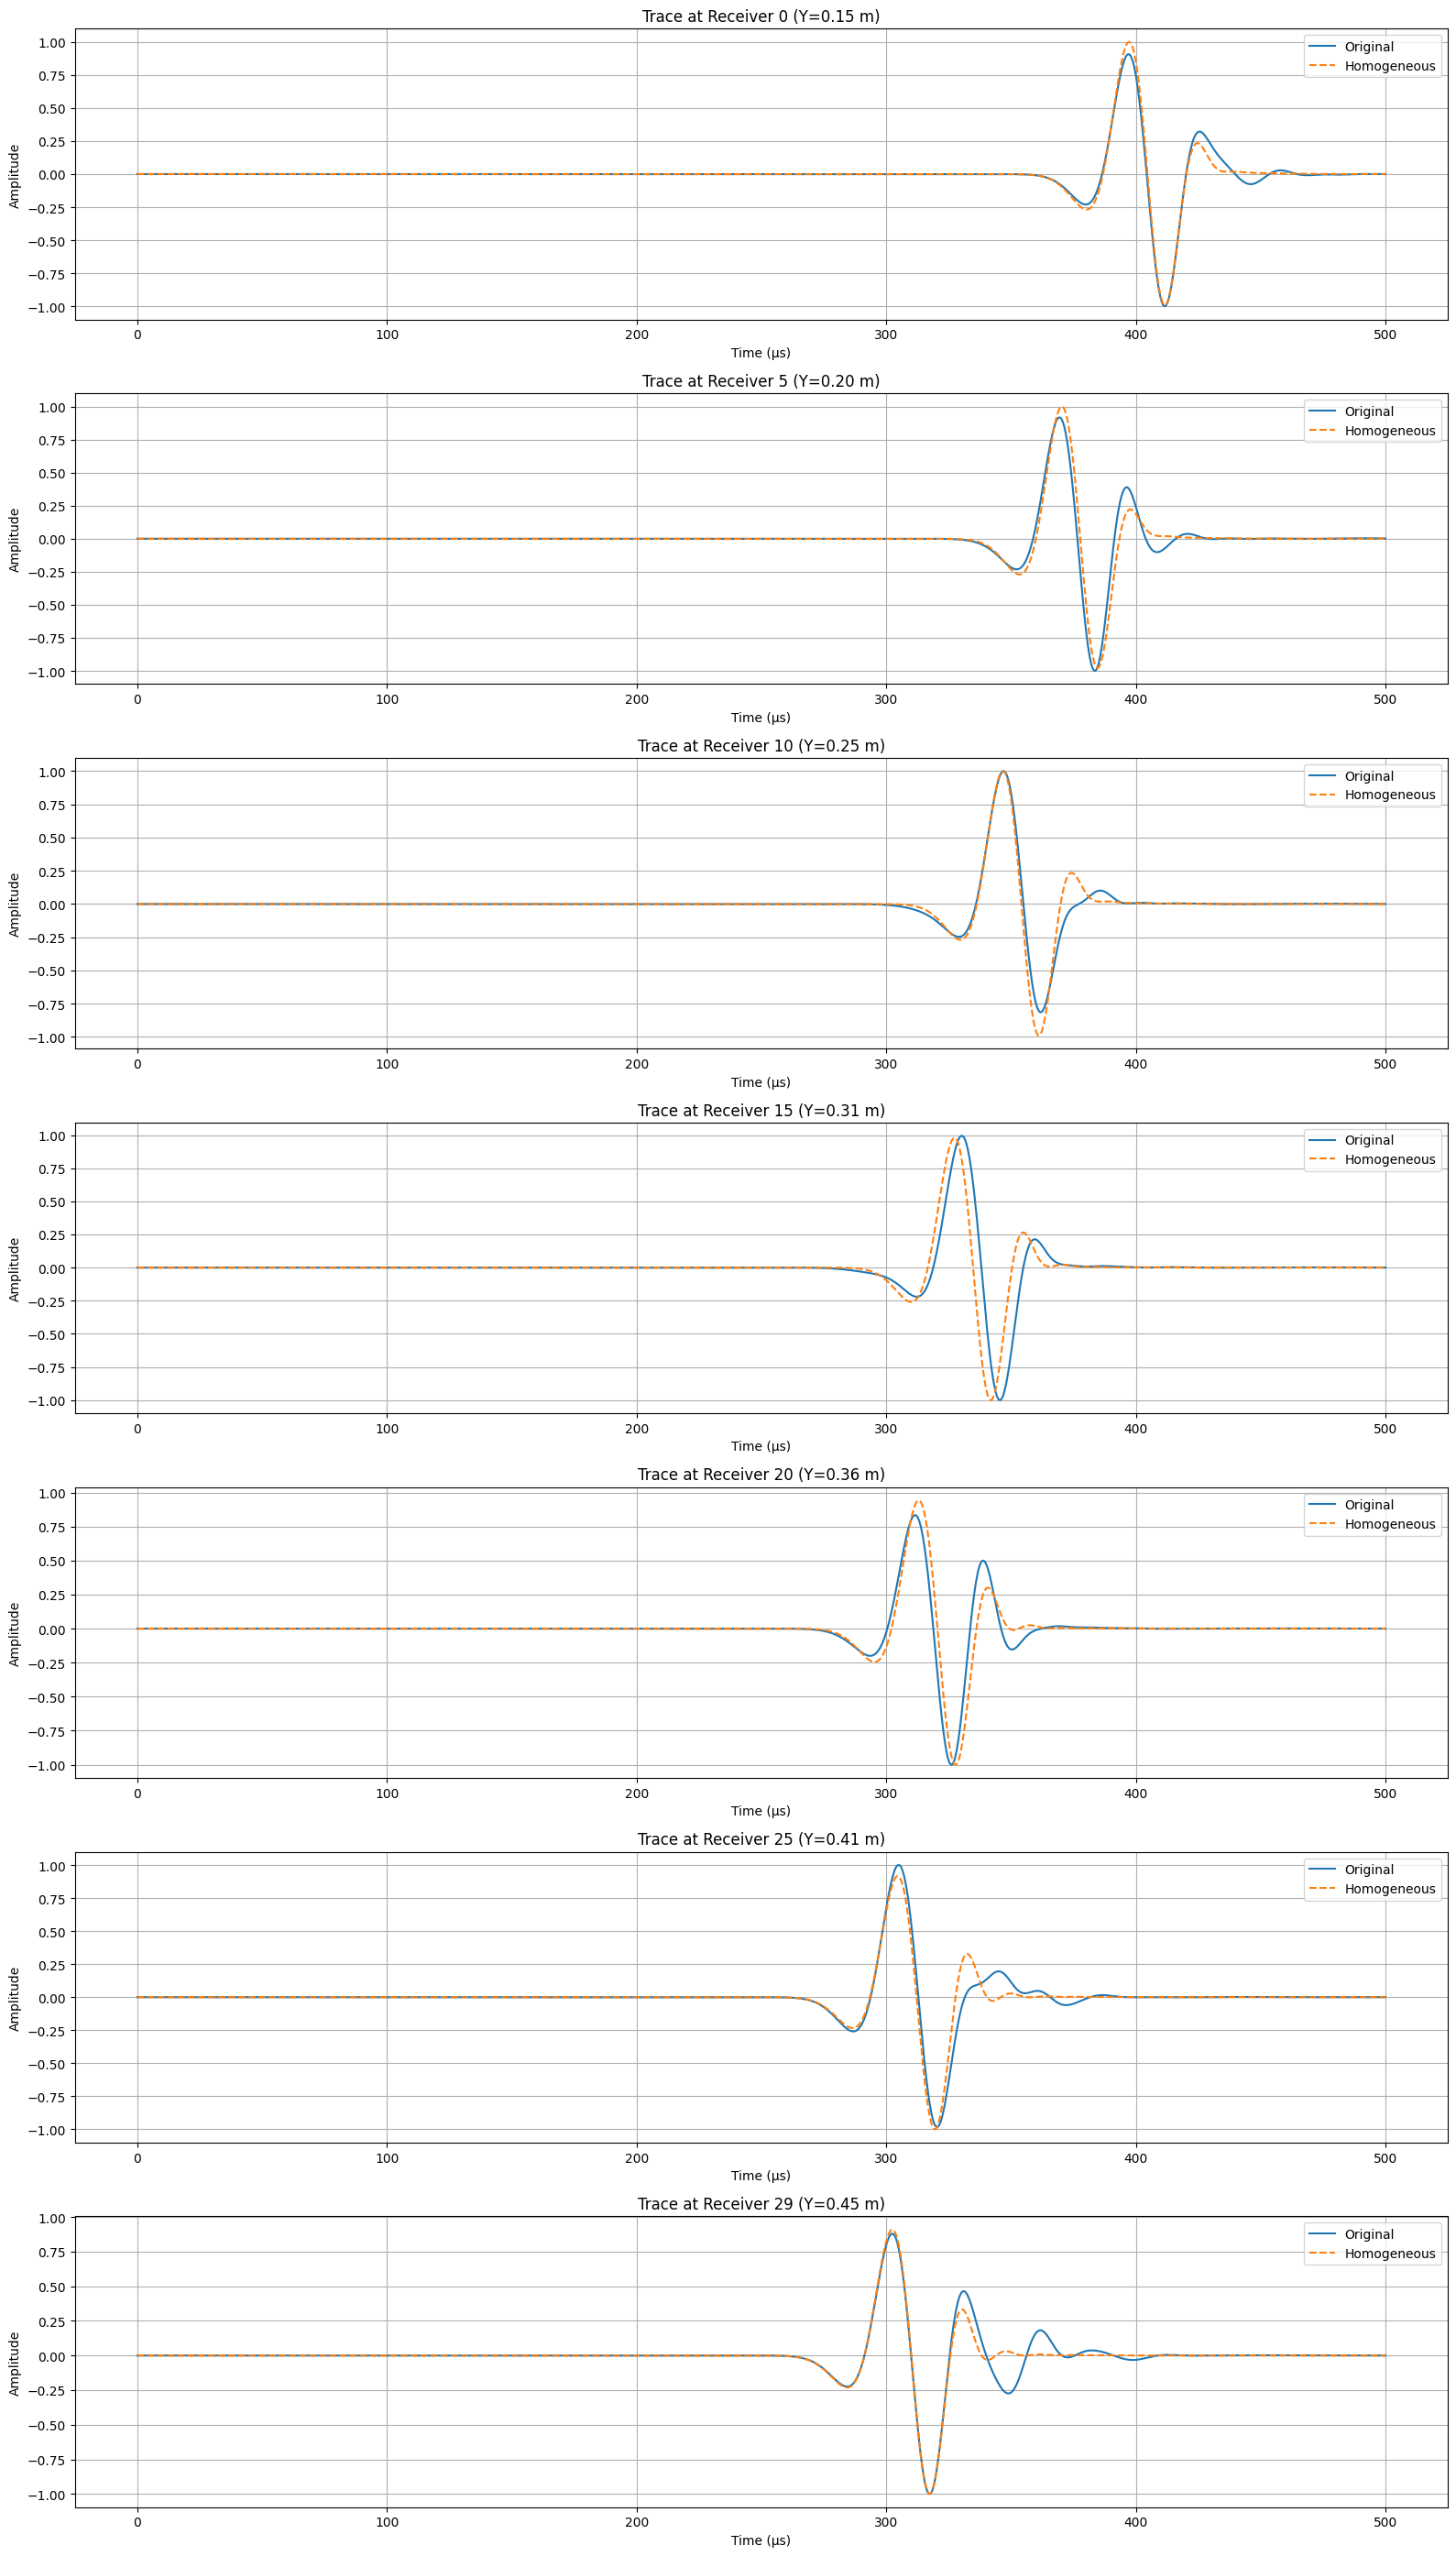

In [33]:

trace_idx = [0,5,10,15,20,25,29]  # indices of traces to plot
# trace_idx = []
src_idx_to_plot = 8

# Create a single big figure with all traces
fig, axes = plt.subplots(len(trace_idx), 1, figsize=(16, 4*len(trace_idx)))

for i, idx in enumerate(trace_idx):
    ax = axes[i] if len(trace_idx) > 1 else axes
    # ax.plot(salvus_time*1e6, salvus_traces[src_idx_to_plot, idx, :]/np.max(np.abs(salvus_traces[src_idx_to_plot, idx, :])), label=f"Salvus Trace {idx}")
    ax.plot(time*1e6, seis_total[src_idx_to_plot, idx,:]/np.max(np.abs(seis_total[src_idx_to_plot, idx,:])), label="Original")
    ax.plot(time*1e6, seis_homo_total[src_idx_to_plot, idx,:]/np.max(np.abs(seis_homo_total[src_idx_to_plot, idx,:])), label="Homogeneous", linestyle='--')
    # ax.plot(time*1e6, seis_traces_disp[src_idx_to_plot, idx,:]/np.max(np.abs(seis_traces_disp[src_idx_to_plot, idx,:])), label="Dispersion-Corrected", linestyle='--')
    # ax.plot(time*1e6, seis_traces_disp_spline_array[src_idx_to_plot, idx,:]/np.max(np.abs(seis_traces_disp_spline_array[src_idx_to_plot, idx,:])), label="Dispersion-Corrected (salvus Spline)", linestyle='--')
    ax.grid()
    ax.set_xlabel('Time (µs)')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'Trace at Receiver {idx} (Y={receiver_is[diag_indices[idx],1]*dx:.2f} m)')
    ax.legend()

plt.tight_layout()
# plt.savefig('diagonal_traces_comparison_dispersive.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Inversion setup

In [34]:
# drop all the variable from GPU memory with JAX
import gc

del seis_total
del seis_homo_total
del seis_traces_disp
del seis_traces_disp_spline
del seis_traces_disp_spline_array

gc.collect()
jax.clear_caches()

In [35]:
salvus_out = np.load("all_traces.npz")
salvus_traces = salvus_out["all_traces"]
salvus_time = salvus_out["t"]
print(salvus_traces.shape, salvus_time.shape, time.shape)
# interpolate salvus_traces to match the time axis of our simulation if needed
# For example, if salvus_traces has a different time sampling, you can use np.interp to interpolate it to the same time points as 'time' used in our simulation.
if len(salvus_time) != len(time):
    salvus_traces_interp = np.zeros((salvus_traces.shape[0], salvus_traces.shape[1], len(time)))
    for i in range(salvus_traces.shape[0]):
        for j in range(salvus_traces.shape[1]):
            salvus_traces_interp[i, j, :] = np.interp(time, salvus_time, salvus_traces[i, j, :])
    salvus_traces = salvus_traces_interp


salvus_traces.shape, time.shape

(9, 900, 4031) (4031,) (1559,)


((9, 900, 1559), (1559,))

In [36]:
# lest normalize each individuals tracs of the salvus data with respect to the maximum absolute value of that trace
salvus_traces_normalized = salvus_traces / jnp.max(jnp.abs(salvus_traces), axis=2, keepdims=True)

In [37]:
# lets remove the center source from the salvus which is 4th source in the list
salvus_traces_normalized = jnp.delete(salvus_traces_normalized, 4, axis=0)
salvus_traces_normalized.shape

(8, 900, 1559)

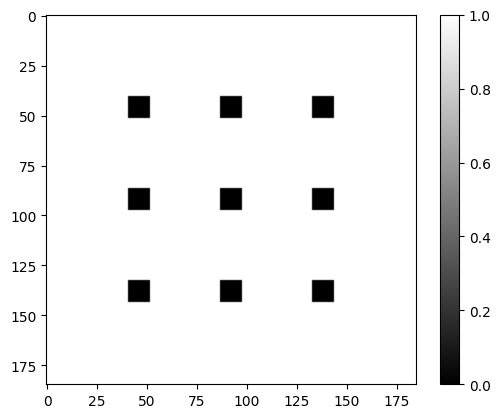

In [38]:
mask = jnp.ones(true_model.shape, dtype=jnp.float32)
# mask the position of the source (and a bit around) to avoid the optimizer trying to fit those areas
for src in range(src_indices.shape[0]):
    radius = 5  # in grid points
    src_x_idx = int(src_indices[src,0])
    src_y_idx = int(src_indices[src,1])
    x_min = max(src_x_idx - radius, 0)
    x_max = min(src_x_idx + radius + 1, mask.shape[0])
    y_min = max(src_y_idx - radius, 0)
    y_max = min(src_y_idx + radius + 1, mask.shape[1])
    mask = mask.at[x_min:x_max, y_min:y_max].set(0.0)


plt.imshow(mask, cmap='gray')
plt.colorbar()

def get_sound_speed(params):
    # limit the range of the sound speed to be between 500 and 1500 m/s using a sigmoid function
    # params = jnp.clip(params, 2000, 4500)
    return params + compose(params)(nn.sigmoid)


In [39]:
# old lax.scan implementation


# def smooth_fun(gradient):
#     # x = gradient.on_grid[..., 0]
#     x = gradient * mask
#     for _ in range(1):
#         x = smooth(x)
#     return x 
# @jit
# def fwi(src_position):
#     # print("source position in fwi", src_position)
#     num_steps_fwi = 1000
#     # num_steps_fwi = 150 # for pml implementation
#     # num_steps_fwi = 80 # for cpml implementation
#     key = random.PRNGKey(42)
#     _, key = random.split(key)
#     # initial model is the blurred model
#     # params_fwi = blurred_model

#     # def simulate_true(src):
#     #     p_rec, _ = acoustic2D_pml_minmem(
#     #         true_model, density, src,
#     #         f0, dx, dy, dt_ben, n_steps_forward,
#     #         receiver_is_modif, pml_width=pml_width, output_wavefield=True
#     #     )
#     #     return p_rec

#     # p_data_obs = vmap(simulate_true)(src_position)  # [Nsrc, Nt, Nrec] is equivalent to making a measurements of the True model with the initial position once every start of the FWI loop

#     init_fun_fwi, update_fun_fwi, get_params_fwi = optimizers.adam(25.0, 0.9, 0.9)
#     # opt_state_fwi = init_fun_fwi(jnp.array((homo_model, density_grid_homo)))
#     opt_state_fwi = init_fun_fwi(homo_model)
#     salvus_data_for_fwi = jnp.array(salvus_traces_normalized)


#     # print(f"Size of data [Source idx, Time, Sensor idx]: {p_data.shape}")

#     def loss_func_fwi(opt_state_fwi, src_num):
#         @jit
#         def simulate_one(src_num):
#             # p_rec, _ = acoustic2D_pml_minmem(
#             #     opt_state_fwi, density, src_position[src_num],
#             #     f0, dx, dy, dt_ben, n_steps_forward,
#             #     receiver_is_modif, pml_width=pml_width, output_wavefield=True
#             # )

#             p_rec = acoustic2D_cpml_minmem(
#                 get_sound_speed(opt_state_fwi), density_grid_homo, src_indices[src_num], f0,
#                 dx, dy, dt, n_steps,
#                 receiver_is=receiver_is,
#                 output_wavefield=True,
#                 pml_width=pml_width,
#                 R_coeff=1e-6, m=3, kappa_max=3.0, alpha_max=None
#             )

#             # apply dispersion to
#             dist_all = jnp.sqrt(
#                     (receiver_is[:,0] - src_indices[src_num,0])**2 +
#                     (receiver_is[:,1] - src_indices[src_num,1])**2) * dx
#             # print(dist_all.shape, p_rec[0].shape)

#             out = apply_dispersion_phase_shift_jax(p_rec[0].T, dt, dist_all, c_ref=c_min, cp_table=(f_A0, c_A0))
#             out_normalized = out / jnp.max(jnp.abs(out), axis=1, keepdims=True)
#             # p_rec_normalized = p_rec[0] / jnp.max(jnp.abs(p_rec[0]), axis=0, keepdims=True)
            


#             return out_normalized
#             # return p_rec_normalized.T
#             # return p_rec[0].T
        
#         # simulate_all = jit(vmap(simulate_one))
#         # p_pred = simulate_all(src_position)
#         # p_pred,_ = acoustic2D_pml_minmem(params_fwi, density, src_position[src_num], f0, dx, dy, dt_ben, n_steps_forward, receiver_is_modif, pml_width=pml_width)
#         p_pred = simulate_one(src_num)

#         # data = seis_traces_disp[src_num]
#         # data = seis_total[src_num]
#         data = salvus_data_for_fwi[src_num]
#         # print(p_pred.shape, data.shape)
#         return jnp.mean((p_pred - data) ** 2)

#     loss_with_grad_fwi = value_and_grad(loss_func_fwi,argnums=0)

#     # Define and compile the update function
#     @jit
#     def update_fwi(opt_state, key, k):
#         v = get_params_fwi(opt_state)
#         src_num = random.choice(key, jnp.array([0,1,2,3,4,5,6,7,8]))
#         lossval, gradient = loss_with_grad_fwi(v, src_num)
#         gradient = smooth_fun(gradient)
#         # gradient *= probabilities[src_num]
#         return lossval, update_fun_fwi(k, gradient, opt_state)

#     @jit
#     def body(carry, k):
#         opt_state, key = carry
#         _, key = random.split(key)      # throw away first, keep second
#         lossval, opt_state = update_fwi(opt_state, key, k)
#         return (opt_state, key), lossval

#     (opt_state_fwi, _), losses = lax.scan(body, (opt_state_fwi, key), jnp.arange(num_steps_fwi))
#     new_params = get_params_fwi(opt_state_fwi)

#     return new_params

In [40]:
def smooth_fun(gradient):
    x = gradient * mask
    for _ in range(1):
        x = smooth(x)
    return x


def fwi(src_position, use_tqdm=True, num_steps_fwi=1000, display_every=10):
    key = random.PRNGKey(42)
    key, _ = random.split(key)

    init_fun_fwi, update_fun_fwi, get_params_fwi = optimizers.adam(
        25.0, 0.9, 0.9
    )
    opt_state = init_fun_fwi(homo_model)

    # Cache once outside the loss
    salvus_data = jnp.asarray(salvus_traces_normalized)
    available_src = jnp.arange(src_position.shape[0])

    def loss_func(params, src_num):
        p_rec = acoustic2D_cpml_minmem(
            get_sound_speed(params),
            density_grid_homo,
            src_indices[src_num],
            f0,
            dx,
            dy,
            dt,
            n_steps,
            receiver_is=receiver_is,
            output_wavefield=True,
            pml_width=pml_width,
            R_coeff=1e-6,
            m=3,
            kappa_max=3.0,
            alpha_max=None,
        )

        dist_all = (
            jnp.sqrt(
                (receiver_is[:, 0] - src_indices[src_num, 0]) ** 2
                + (receiver_is[:, 1] - src_indices[src_num, 1]) ** 2
            )
            * dx
        )

        pred = apply_dispersion_phase_shift_jax(
            p_rec[0].T,
            dt,
            dist_all,
            c_ref=c_min,
            cp_table=(f_A0, c_A0),
        )

        pred = pred / jnp.maximum(
            jnp.max(jnp.abs(pred), axis=1, keepdims=True), 1e-12
        )

        data = salvus_data[src_num]
        return jnp.mean((pred - data) ** 2)

    loss_with_grad = value_and_grad(loss_func, argnums=0)

    @jit
    def update_step(opt_state, key, step_idx):
        params = get_params_fwi(opt_state)
        key, subkey = random.split(key)
        src_num = random.choice(subkey, available_src)

        loss_value, gradient = loss_with_grad(params, src_num)
        gradient = smooth_fun(gradient)
        opt_state = update_fun_fwi(step_idx, gradient, opt_state)

        return opt_state, key, loss_value, src_num

    if use_tqdm:
        losses = []
        chosen_sources = []

        # Warmup compile once
        opt_state, key, loss_value, src_num = update_step(opt_state, key, 0)
        loss_scalar = float(loss_value.block_until_ready())
        losses.append(loss_scalar)
        chosen_sources.append(int(src_num))

        pbar = trange(1, num_steps_fwi, desc="FWI", dynamic_ncols=True)
        for step_idx in pbar:
            opt_state, key, loss_value, src_num = update_step(
                opt_state, key, step_idx
            )

            if step_idx % display_every == 0:
                loss_scalar = float(loss_value.block_until_ready())
                pbar.set_postfix(loss=f"{loss_scalar:.3e}", src=int(src_num))
            else:
                loss_scalar = float(loss_value)

            losses.append(loss_scalar)
            chosen_sources.append(int(src_num))

        final_params = get_params_fwi(opt_state)
        return final_params, jnp.asarray(losses), jnp.asarray(chosen_sources)

    else:
        @jit
        def run_scan(opt_state, key):
            def body(carry, step_idx):
                opt_state, key = carry
                opt_state, key, loss_value, src_num = update_step(
                    opt_state, key, step_idx
                )
                return (opt_state, key), (loss_value, src_num)

            (opt_state, key), (losses, chosen_sources) = lax.scan(
                body,
                (opt_state, key),
                jnp.arange(num_steps_fwi),
            )
            return opt_state, key, losses, chosen_sources

        opt_state, key, losses, chosen_sources = run_scan(opt_state, key)
        final_params = get_params_fwi(opt_state)
        return final_params, losses, chosen_sources

In [41]:
src_num = 0
p_rec = acoustic2D_cpml_minmem(
                true_model, density_grid_homo, src_indices[src_num], f0,
                dx, dy, dt, n_steps,
                receiver_is=receiver_is,
                output_wavefield=True,
                pml_width=pml_width,
                R_coeff=1e-6, m=3, kappa_max=3.0, alpha_max=None
            )

# apply dispersion to
dist_all = jnp.sqrt(
        (receiver_is[:,0] - src_indices[src_num,0])**2 +
        (receiver_is[:,1] - src_indices[src_num,1])**2) * dx
# print(dist_all.shape, p_rec[0].shape)

out = apply_dispersion_phase_shift_jax(p_rec[0].T, dt, dist_all, c_ref=c_min, cp_table=(f_A0, c_A0))

# lets also normalize each trace
out_normalized = out / np.max(np.abs(out), axis=1, keepdims=True)

p_rec_normalized = p_rec[0] / np.max(np.abs(p_rec[0]), axis=0, keepdims=True)
            

In [42]:
p_rec[0].shape, p_rec_normalized.shape, out.shape, out_normalized.shape, salvus_traces_normalized[src_num].shape

((1559, 900), (1559, 900), (900, 1559), (900, 1559), (900, 1559))

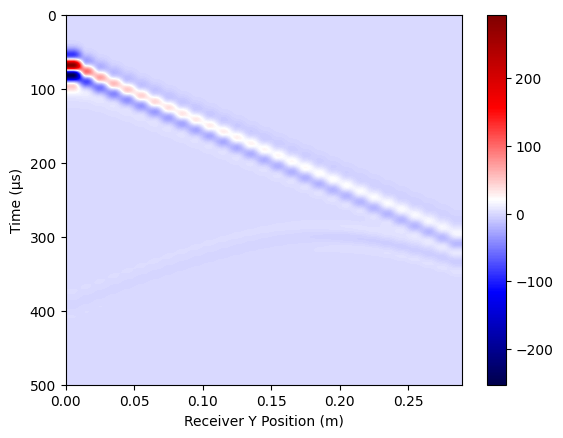

In [43]:
plt.imshow(p_rec[0][:,:29], aspect='auto', cmap='seismic',extent=[receiver_is[:29,1].min() * dx -0.15, receiver_is[:29,1].max() * dx -0.15, T*1e6,0])
plt.ylabel('Time (µs)')
plt.xlabel('Receiver Y Position (m)')
plt.colorbar()

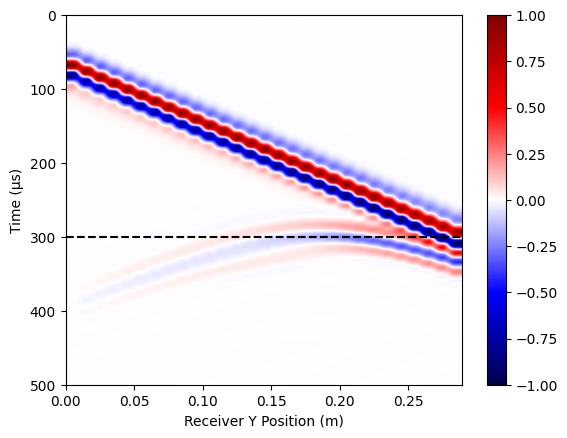

In [44]:
plt.imshow(p_rec_normalized[:,:29], aspect='auto', cmap='seismic' ,extent=[ receiver_is[:29,1].min() * dx -0.15, receiver_is[:29,1].max() * dx -0.15, T*1e6,0])
plt.axhline(y=300, color='k', linestyle='--')
plt.ylabel('Time (µs)')
plt.xlabel('Receiver Y Position (m)')
plt.colorbar()

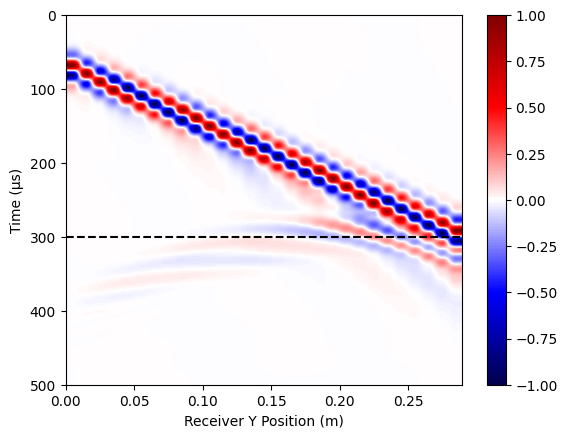

In [45]:
# plota shot gather
plt.imshow(out_normalized[0:29].T, aspect='auto', cmap='seismic',extent=[ receiver_is[0:29,1].min() * dx - 0.15, receiver_is[0:29,1].max() * dx - 0.15,T*1e6,0]   )
plt.axhline(y=300, color='k', linestyle='--', label="300 µs")
plt.ylabel('Time (µs)')
plt.xlabel('Receiver Y Position (m)')
plt.colorbar()

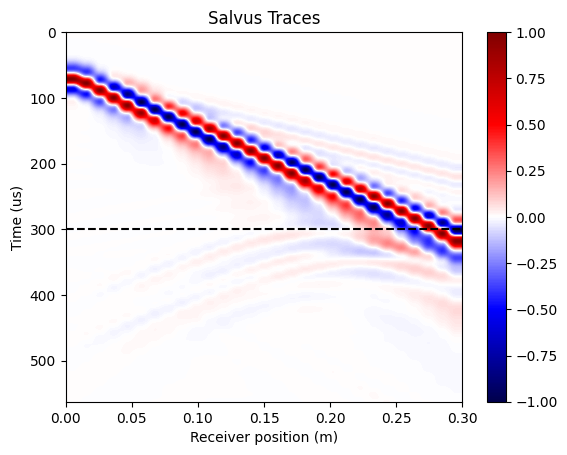

In [46]:
plt.imshow(salvus_traces_normalized[src_num,0:29,:].T, aspect='auto', cmap='seismic',extent=[0,30*0.01, salvus_time[-1]*1e6,salvus_time[0]*1e6])
plt.axhline(y=300, color='k', linestyle='--', label="300 µs")
plt.ylabel('Time (us)')
plt.xlabel('Receiver position (m)')
plt.title('Salvus Traces')
plt.colorbar()

In [47]:
p_rec[0][:,0:29].shape

(1559, 29)

In [48]:
print(jnp.mean((out[0:29].T - salvus_traces_interp[src_num,0:29,:].T) ** 2))
print(jnp.mean((p_rec[0][:,0:29] - salvus_traces_interp[src_num,0:29,:].T) ** 2))

121.69843
121.69789


In [49]:
print(jnp.mean((p_rec_normalized[:,0:29] - salvus_traces_normalized[src_num,0:29,:].T) ** 2))
print(jnp.mean((out_normalized[0:29].T - salvus_traces_normalized[src_num,0:29,:].T) ** 2))


0.05584771
0.057575937


In [50]:
# initial model is the blurred model
params = jnp.array(homo_model)

# iin = fwi(src_indices)
# live progress bar
iin, losses, chosen_sources = fwi(src_indices, use_tqdm=True)



FWI: 100%|██████████| 999/999 [01:57<00:00,  8.48it/s, loss=5.829e-02, src=4]


Text(0, 0.5, 'Loss')

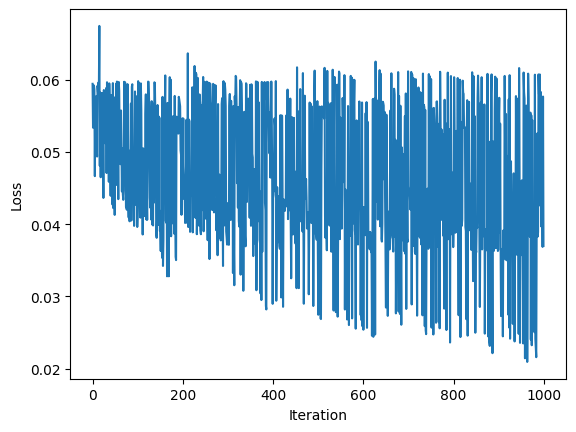

In [51]:
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')

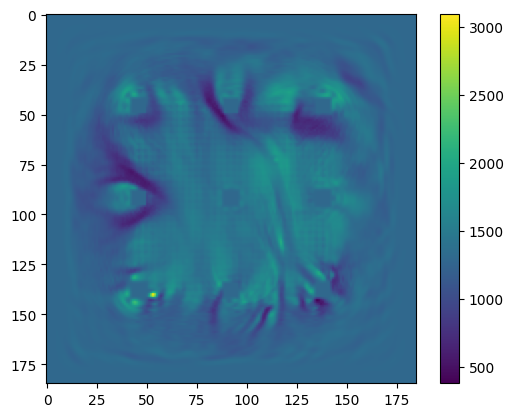

velocity L1 loss: 78198.8


In [52]:
plt.imshow(iin, cmap='viridis')
plt.colorbar()
plt.show()
# L1 loss
print("velocity L1 loss:", jnp.linalg.norm((iin - jnp.fliplr(true_model)), ord=1))


In [53]:
simulate_for_source = lambda source_i: acoustic2D_cpml_minmem(
                homo_model, density_grid, source_i, f0,
                dx, dy, dt, n_steps,
                receiver_is=receiver_is,
                output_wavefield=True,
                pml_width=pml_width,
                R_coeff=1e-6, m=3, kappa_max=3.0, alpha_max=None
            )
#     # simulate_for_source = lambda source_i: acoustic2D_pml_4th_minmem(true_model, density, source_i, f0, dx, dy, dt_ben, n_steps, receiver_is_modif, pml_width=10)
p_data_homo, _ = vmap(simulate_for_source)(src_indices)  # [Nsrc, Nt, Nrec]
# swap the last 2 dimensions
p_data_homo = p_data_homo.transpose(0, 2, 1)  # [Nsrc, Nrec, Nt]
print(len(p_data_homo))

9


In [ ]:
simulate_for_source = lambda source_i: acoustic2D_cpml_minmem(
                iin, density_grid, source_i, f0,
                dx, dy, dt, n_steps,
                receiver_is=receiver_is,
                output_wavefield=True,
                pml_width=pml_width,
                R_coeff=1e-6, m=3, kappa_max=3.0, alpha_max=None
            )
#     # simulate_for_source = lambda source_i: acoustic2D_pml_4th_minmem(true_model, density, source_i, f0, dx, dy, dt_ben, n_steps, receiver_is_modif, pml_width=10)
p_data_final, _ = vmap(simulate_for_source)(src_indices)  # [Nsrc, Nt, Nrec]
# swap the last 2 dimensions
p_data_final = p_data_final.transpose(0, 2, 1)  # [Nsrc, Nrec, Nt]
print(len(p_data_final))

In [ ]:
# load the same traces as above to compare with the simulated traces from the initial model
salvus_out = np.load("all_traces.npz")
salvus_traces = salvus_out["all_traces"]
salvus_time = salvus_out["t"]
# print(salvus_traces.shape, salvus_time.shape, time.shape,seis_traces_disp.shape, p_data_final.shape)

# lets normalize the salvus traces as well
salvus_traces_normalized = salvus_traces / jnp.max(jnp.abs(salvus_traces), axis=2, keepdims=True)

# plot the traces for the first source
trace_idx = [0,5,10,15,20,25,29]  # indices of traces to plot
src_idx_to_plot = 8

# Create a single big figure with all traces
fig, axes = plt.subplots(len(trace_idx), 1, figsize=(16, 4*len(trace_idx)))

for i, idx in enumerate(trace_idx):
    ax = axes[i] if len(trace_idx) > 1 else axes
    ax.plot(salvus_time*1e6, salvus_traces[src_idx_to_plot, idx, :]/np.max(np.abs(salvus_traces[src_idx_to_plot, idx, :])), label=f"Salvus Trace {idx}")
    # ax.plot(time*1e6, seis_total[src_idx_to_plot, idx,:]/np.max(np.abs(seis_total[src_idx_to_plot, idx,:])), label="Original")
    # ax.plot(time*1e6, seis_homo_total[src_idx_to_plot, idx,:]/np.max(np.abs(seis_homo_total[src_idx_to_plot, idx,:])), label="Homogeneous", linestyle='--')
    # ax.plot(time*1e6, seis_traces_disp[src_idx_to_plot, idx,:]/np.max(np.abs(seis_traces_disp[src_idx_to_plot, idx,:])), label="Dispersion-Corrected", linestyle='--')
    ax.plot(time*1e6, p_data_homo[src_idx_to_plot, idx,:]/np.max(np.abs(p_data_homo[src_idx_to_plot, idx,:])), label="Homogeneous", linestyle='--')
    # ax.plot(time*1e6, seis_traces_disp_spline_array[src_idx_to_plot, idx,:]/np.max(np.abs(seis_traces_disp_spline_array[src_idx_to_plot, idx,:])), label="Dispersion-Corrected (Spline)", linestyle='--')
    ax.plot(time*1e6,p_data_final[src_idx_to_plot, idx,:]/np.max(np.abs(p_data_final[src_idx_to_plot, idx,:])), label="Final inverted", linestyle='--')
    ax.grid()
    ax.set_xlabel('Time (µs)')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'Trace at Receiver {idx} (Y={receiver_is[diag_indices[idx],1]*dx:.2f} m)')
    ax.legend()

plt.tight_layout()
# plt.savefig('diagonal_traces_comparison_dispersive.pdf', format='pdf', bbox_inches='tight')
plt.show()
